# Business Case Study: Employee Salary Analysis using Normal Distribution

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data= pd.read_excel('employee_salary_dataset_500.xlsx')

In [3]:
data.head()

,Employee_ID,Department,Experience_Years,Salary
0,1001,Operations,2,61337
1,1002,Sales,3,56004
2,1003,Operations,2,47495
3,1004,HR,10,39874
4,1005,Marketing,1,60521


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Employee_ID       500 non-null    int64 
 1   Department        500 non-null    object
 2   Experience_Years  500 non-null    int64 
 3   Salary            500 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 15.8+ KB


In [5]:
data.duplicated().sum()

np.int64(0)

# 

### Business Questions

#### 1. What is the average salary of employees?

In [6]:
data['Salary'].mean()

np.float64(55229.826)

In [8]:
mean_salary = data['Salary'].mean()
print(f"Average Salary: ₹{mean_salary:.2f}")

Average Salary: ₹55229.83


#### 2. How much variation is there in employee salaries?

In [9]:
data['Salary'].std()

11318.292690267783

In [12]:
salary_std = data['Salary'].std()
print(f'Standard Deviation: ₹{salary_std:.2f}')

Standard Deviation: ₹11318.29


##### Standard deviation =  ₹11,318 means most employee salaries fall roughly ₹11,318 above or below the average

# 

#### 3. Does the salary distribution appear approximately normal

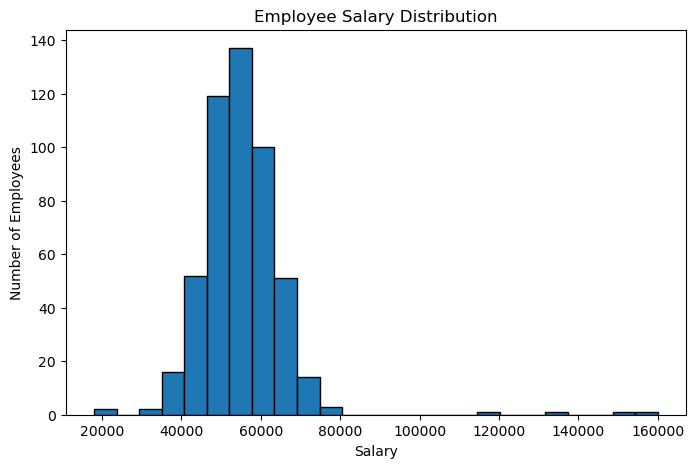

In [17]:
plt.figure(figsize=(8,5))
plt.hist(data['Salary'], bins=25, edgecolor='black')
plt.title('Employee Salary Distribution')
plt.xlabel('Salary')
plt.ylabel('Number of Employees')
plt.show()

 - Most salaries are concentrated between ₹45,000–₹65,000.
- It looks approximately bell-shaped.
- There are a few very high salaries, which create a slight right skew.

<Axes: ylabel='Density'>

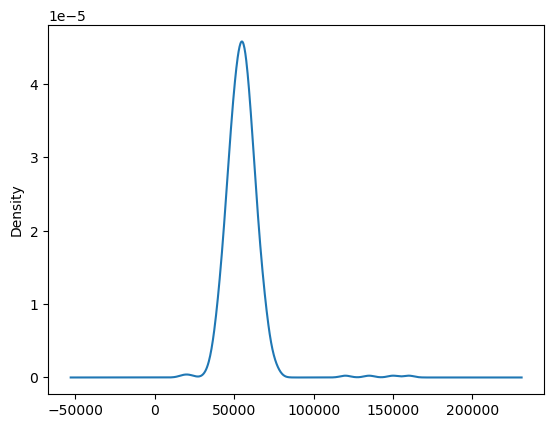

In [27]:
data['Salary'].plot(kind='kde')

 - Most salaries are concentrated around the average.

<Axes: ylabel='Density'>

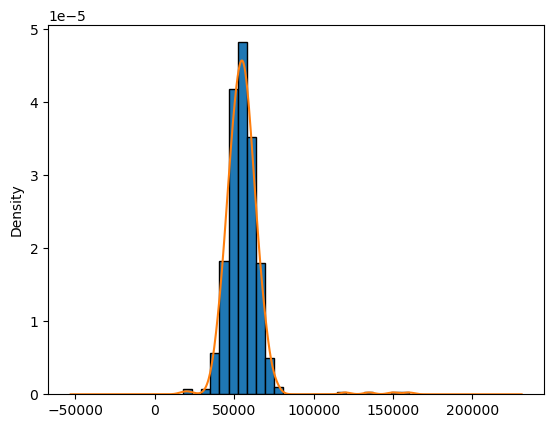

In [31]:
plt.hist(data['Salary'], bins=25, edgecolor='black',density=True)
data['Salary'].plot(kind='kde')

In [32]:
print('Mean :', data['Salary'].mean())
print('Median :', data['Salary'].median())

Mean : 55229.826
Median : 54870.5


In [36]:
data['Salary'].mean() - data['Salary'].median()

np.float64(359.32600000000093)

# 

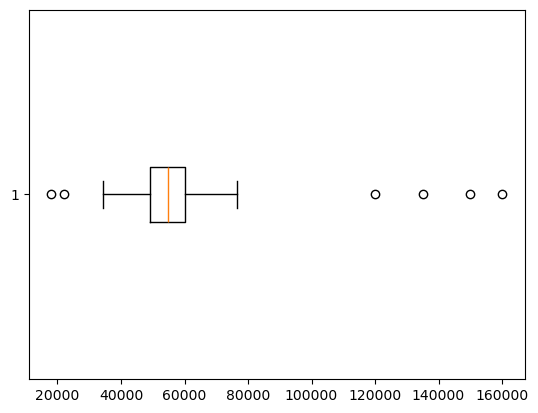

In [33]:
plt.boxplot(data['Salary'], vert=False)
plt.show()

 - Most employees are inside the box.
- A few salaries are extremely high. 
- Those circles on the right and left side  are outliers.

##### Therefore, the salary data can be considered approximately normally distributed.

# 

#### 4. Where are most employee salaries concentrated? Identify the salary range where most employees fall.

In [39]:
lower_salary = mean_salary - salary_std

In [40]:
lower_salary

np.float64(43911.533309732215)

In [41]:
upper_salary = mean_salary + salary_std

In [42]:
upper_salary

np.float64(66548.11869026779)

In [46]:
print(f'{lower_salary:.2f} - {upper_salary:.2f} salary range contains most employees?')

43911.53 - 66548.12 salary range contains most employees?


In [51]:
print(f'Mean Salary : {mean_salary:.2f}')
print(f'Standard Deviation : {salary_std:.2f}')

print(f'\nSalary Range (Mean ± 1 SD)')
print(f'Lower Limit : {lower_salary:.2f}')
print(f'Upper Limit : {upper_salary:.2f}')

Mean Salary : 55229.83
Standard Deviation : 11318.29

Salary Range (Mean ± 1 SD)
Lower Limit : 43911.53
Upper Limit : 66548.12


# 

#### 5. Calculate the following salary ranges:
- Mean ± 1 Standard Deviation 
- Mean ± 2 Standard Deviations 
- Mean ± 3 Standard Deviations

In [55]:
# Mean ± 2 SD
lower_2 = mean_salary - (2 * salary_std)
upper_2 = mean_salary + (2 *salary_std)

In [56]:
lower_2

np.float64(32593.240619464435)

In [58]:
upper_2

np.float64(77866.41138053557)

In [61]:
# Mean ± 3 SD
lower_3 = mean_salary - (3 * salary_std)
upper_3 = mean_salary + (3 *salary_std)

In [69]:
print(f'Mean Salary : {mean_salary:.2f}')
print("Standard Deviation:", round(salary_std,2))

print('\nMean ± 1 SD')
print(f'{lower_salary:.2f} to {upper_salary:.2f}')

print('\nMean ± 2 SD')
print(f'{lower_2:.2f} to {upper_2:.2f}')

print('\nMean ± 3 SD')
print(f'{lower_3:.2f} to {upper_3:.2f}')

Mean Salary : 55229.83
Standard Deviation: 11318.29

Mean ± 1 SD
43911.53 to 66548.12

Mean ± 2 SD
32593.24 to 77866.41

Mean ± 3 SD
21274.95 to 89184.70


# 

# 

#### 6. How many employees fall within: \
- ±1 Standard Deviation 
- ±2 Standard Deviations 
- ±3 Standard Deviations

In [84]:
employees_1ss = data[(data["Salary"] >= lower_salary) &(data["Salary"] <= upper_salary)]

In [85]:
print("Employees within ±1 SD:", len(employees_1ss))
percentage = (len(employees_1ss) / len(data)) * 100
print(f"Percentage: {percentage:.2f}%")

Employees within ±1 SD: 412
Percentage: 82.40%


# 

In [168]:
employees_2nd = data[(data["Salary"] >= lower_2) &(data["Salary"] <= upper_2)]

In [169]:
print("Employees within ±2 SD:", len(employees_2nd))
percentage = (len(employees_2nd) / len(data)) * 100
print(f"Percentage: {percentage:.2f}%")

Employees within ±2 SD: 494
Percentage: 98.80%


# 

In [87]:
employees_3rd = data[(data["Salary"] >= lower_3) &(data["Salary"] <= upper_3)]

In [88]:
print("Employees within ±3 SD:", len(employees_3rd))
percentage = (len(employees_3rd) / len(data)) * 100
print(f"Percentage: {percentage:.2f}%")

Employees within ±3 SD: 495
Percentage: 99.00%


# 

#### 7. Which employees have salaries above the company average?

In [89]:
mean_salary

np.float64(55229.826)

In [91]:
data[data['Salary']>mean_salary].shape

(238, 4)

In [92]:
above_avg_s =data[data['Salary']>mean_salary]

In [94]:
above_avg_s.head()

,Employee_ID,Department,Experience_Years,Salary
0,1001,Operations,2,61337
1,1002,Sales,3,56004
4,1005,Marketing,1,60521
5,1006,IT,10,56045
6,1007,HR,9,58662


In [95]:
above_avg_s.tail()

,Employee_ID,Department,Experience_Years,Salary
492,1493,Marketing,2,57839
493,1494,Marketing,2,56832
495,1496,HR,10,58030
497,1498,Finance,14,58584
499,1500,HR,5,63285


In [98]:
above_avg_s['Salary'].mean()

np.float64(62693.008403361346)

In [99]:
mean_salary

np.float64(55229.826)

In [101]:
print('Employees earning above average salary:', len(above_avg_s))

Employees earning above average salary: 238


In [103]:
percentage_above = (len(above_avg_s) / len(data)) * 100
print('Percentage: ' ,round(percentage_above,),"%")

Percentage:  48 %


##### Why is it not exactly 50%?

- Mean is not the middle value (Median is).
- A few high salary outliers can pull the mean upward.
- Therefore, the number of employees above and below the mean may not be exactly equal.

#### 8. Which employees have salaries below the company average

In [106]:
below_avg_s =data[data['Salary']< mean_salary]

In [107]:
below_avg_s.head()

,Employee_ID,Department,Experience_Years,Salary
2,1003,Operations,2,47495
3,1004,HR,10,39874
8,1009,Sales,8,42664
9,1010,HR,13,47251
10,1011,Sales,12,49292


In [109]:
count_below = len(below_avg_s)

In [110]:
print('Employees earning below average salary:', count_below)

Employees earning below average salary: 262


In [114]:
percentage_below = (count_below/ len(data)) * 100
print('Percentage: ' ,round(percentage_below),"%")

Percentage:  52 %


# 

#### 9. Calculate the Z-score for every employee. Create a new column named: Salary_ZScore

In [120]:
data['Salary_ZScore'] = (data["Salary"] - mean_salary) / salary_std

In [121]:
data.head()

,Employee_ID,Department,Experience_Years,Salary,Salary_ZScore
0,1001,Operations,2,61337,0.539584
1,1002,Sales,3,56004,0.068400
2,1003,Operations,2,47495,-0.683392
3,1004,HR,10,39874,-1.356726
4,1005,Marketing,1,60521,0.467489


In [122]:
data["Salary_ZScore"] = data["Salary_ZScore"].round(2)

In [123]:
data.head()

,Employee_ID,Department,Experience_Years,Salary,Salary_ZScore
0,1001,Operations,2,61337,0.54
1,1002,Sales,3,56004,0.07
2,1003,Operations,2,47495,-0.68
3,1004,HR,10,39874,-1.36
4,1005,Marketing,1,60521,0.47


# 

#### 10. Which employees have: 
- Positive Z-score
- Negative Z-score
- Z-score close to zero   
  What does each group indicate?

- Positive Z-score → Salary above the company average.
- Negative Z-score → Salary below the company average.
- Z-score close to 0 → Salary very close to the company average.

###### Employees with Positive Z-score

In [131]:
data[data['Salary_ZScore'] > 0].head()

,Employee_ID,Department,Experience_Years,Salary,Salary_ZScore
0,1001,Operations,2,61337,0.54
1,1002,Sales,3,56004,0.07
4,1005,Marketing,1,60521,0.47
5,1006,IT,10,56045,0.07
6,1007,HR,9,58662,0.30


In [132]:
positive_z = data[data['Salary_ZScore'] > 0]

In [127]:
positive_z.head()

,Employee_ID,Department,Experience_Years,Salary,Salary_ZScore
0,1001,Operations,2,61337,0.54
1,1002,Sales,3,56004,0.07
4,1005,Marketing,1,60521,0.47
5,1006,IT,10,56045,0.07
6,1007,HR,9,58662,0.30


In [133]:
len(positive_z)

236

In [134]:
print("Employees with Positive Z-score:", len(positive_z))

Employees with Positive Z-score: 236


# 

###### Employees with Negative Z-score

In [135]:
negative_z = data[data['Salary_ZScore'] < 0]

In [136]:
negative_z.head()

,Employee_ID,Department,Experience_Years,Salary,Salary_ZScore
2,1003,Operations,2,47495,-0.68
3,1004,HR,10,39874,-1.36
8,1009,Sales,8,42664,-1.11
9,1010,HR,13,47251,-0.70
10,1011,Sales,12,49292,-0.52


In [137]:
print("Employees with Negative Z-score:", len(negative_z))

Employees with Negative Z-score: 260


# 

###### Employees Close to the Mean

In [140]:
close_to_mean = data[(data['Salary_ZScore'] >= -0.10) &(data['Salary_ZScore'] <= 0.10)]

In [141]:
close_to_mean.head()

,Employee_ID,Department,Experience_Years,Salary,Salary_ZScore
1,1002,Sales,3,56004,0.07
5,1006,IT,10,56045,0.07
18,1019,Finance,10,56077,0.07
35,1036,Operations,8,55080,-0.01
41,1042,HR,3,55547,0.03


In [143]:
print("Employees with Z-score close to 0:", len(close_to_mean))

Employees with Z-score close to 0: 61


# 

#### 11. Identify Employees with Unusual and Extreme Salaries

In [159]:
# Employees with unusual salaries
unusual_salary = data[data['Salary_ZScore'].abs() > 2]

In [160]:
unusual_salary

,Employee_ID,Department,Experience_Years,Salary,Salary_ZScore
15,1016,HR,15,120000,5.72
89,1090,IT,2,135000,7.05
180,1181,Marketing,13,150000,8.37
275,1276,IT,6,18000,-3.29
420,1421,Finance,12,22000,-2.94
470,1471,Operations,2,160000,9.26


In [162]:
print('Number of employees with unusual salaries:', len(unusual_salary))

Number of employees with unusual salaries: 6


# 

In [164]:
# Employees with extreme salaries
extreme_salary =  data[data['Salary_ZScore'].abs() > 3]

In [166]:
extreme_salary

,Employee_ID,Department,Experience_Years,Salary,Salary_ZScore
15,1016,HR,15,120000,5.72
89,1090,IT,2,135000,7.05
180,1181,Marketing,13,150000,8.37
275,1276,IT,6,18000,-3.29
470,1471,Operations,2,160000,9.26


In [167]:
print("Number of employees with extreme salaries:", len(extreme_salary))

Number of employees with extreme salaries: 5
